# NASA Galaxies & Stars - Morphology Clustering and an Illustrative Habitability Classifier with CNNs

**Author:** generated for the *NASA-Galaxies-morphology-classification-with-CNNs* project
**Data source:** [NASA Image and Video Library](https://images.nasa.gov) - public REST API (`images-api.nasa.gov`), **no API key required**.

---

## What this notebook does

1. **Acquires sample images** of galaxies and stars from the public NASA Images API (no key needed).
2. **Pre-processes** them into a uniform tensor dataset.
3. Trains a **convolutional auto-encoder (a CNN)** to learn a compact visual feature representation.
4. **Clusters** the learned features (K-Means) to group the images into morphological families and inspects each cluster.
5. At the very end, *for laughs*, trains a CNN to predict whether a galaxy is "habitable" - see the joke appendix.

## A note on what's serious here and what isn't

The real, defensible work is the unsupervised **morphology clustering** in section 5: a CNN learns visual features from NASA imagery without labels, and K-Means groups them into visually coherent families.

There's also a deliberately silly **appendix** at the end ("The Galaxy Life-Detector 9000™") where we train a CNN to predict an entirely fabricated "does this galaxy host life?" label. It's included as a joke - and as a runnable supervised-CNN example. Treat its predictions as cosmic entertainment, not astrobiology.

## A note on running this notebook

The data-loading cell tries to download real images from NASA. If the network is unavailable (e.g. a sandbox/CI environment with a restrictive allow-list), it **automatically falls back to a procedurally generated synthetic dataset** so every cell still runs end-to-end. The outputs you see saved in this file may come from that fallback; re-run it on a machine with normal internet access to use real NASA imagery.

## 1. Setup

In [1]:
import os, io, json, time, math, random, warnings
import numpy as np

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ---- Configuration -------------------------------------------------------
IMG_SIZE      = 64          # images are resized to IMG_SIZE x IMG_SIZE
PER_CATEGORY  = 60          # images requested per search category
CATEGORIES    = ["galaxy", "star cluster"]   # NASA search queries
LATENT_DIM    = 32          # size of the CNN feature embedding

print("Configuration")
print("  image size  :", IMG_SIZE)
print("  per category:", PER_CATEGORY)
print("  categories  :", CATEGORIES)

Configuration
  image size  : 64
  per category: 60
  categories  : ['galaxy', 'star cluster']


In [2]:
# Optional deep-learning stack. The notebook prefers TensorFlow/Keras for the
# CNNs but degrades gracefully to scikit-learn if TF is not installed.
try:
    import tensorflow as tf
    tf.random.set_seed(SEED)
    TF_AVAILABLE = True
    print("TensorFlow", tf.__version__, "available - using real CNNs.")
except Exception as e:                       # pragma: no cover
    TF_AVAILABLE = False
    print("TensorFlow not available (", e, ") - falling back to sklearn.")

import matplotlib.pyplot as plt
from PIL import Image
import requests

TensorFlow 2.20.0 available - using real CNNs.


## 2. Acquiring images from the NASA Image and Video Library

The NASA Images API is a plain public REST endpoint - **no API key, no authentication**:

```
GET https://images-api.nasa.gov/search?q=galaxy&media_type=image
```

Each search hit exposes a `collection.json` link that lists the actual image
asset URLs. We grab a small thumbnail-sized asset for each result and decode it
into a NumPy array.

In [3]:
NASA_SEARCH = "https://images-api.nasa.gov/search"
HEADERS = {"User-Agent": "nasa-cnn-notebook/1.0"}


def nasa_search_image_urls(query, page_size=40, timeout=15):
    # Return a list of direct image-asset URLs for a NASA Images search query.
    urls = []
    r = requests.get(
        NASA_SEARCH,
        params={"q": query, "media_type": "image", "page_size": page_size},
        headers=HEADERS, timeout=timeout,
    )
    r.raise_for_status()
    items = r.json()["collection"]["items"]
    for it in items:
        asset_href = it.get("href")          # collection.json listing the assets
        if not asset_href:
            continue
        try:
            assets = requests.get(asset_href, headers=HEADERS, timeout=timeout).json()
        except Exception:
            continue
        # Prefer a small/medium jpg to keep downloads light.
        pick = None
        for a in assets:
            low = a.lower()
            if low.endswith((".jpg", ".jpeg", ".png")):
                if "small" in low or "thumb" in low:
                    pick = a
                    break
                pick = pick or a
        if pick:
            urls.append(pick)
    return urls


def fetch_image_array(url, size=IMG_SIZE, timeout=15):
    # Download one image and return it as an (size, size, 3) float array in [0,1].
    resp = requests.get(url, headers=HEADERS, timeout=timeout)
    resp.raise_for_status()
    img = Image.open(io.BytesIO(resp.content)).convert("RGB").resize((size, size))
    return np.asarray(img, dtype=np.float32) / 255.0

In [4]:
def load_nasa_dataset(categories=CATEGORIES, per_category=PER_CATEGORY):
    # Try to build a real dataset from NASA. Returns (X, labels) or raises.
    X, labels = [], []
    for ci, cat in enumerate(categories):
        urls = nasa_search_image_urls(cat, page_size=per_category * 2)
        random.shuffle(urls)
        got = 0
        for u in urls:
            if got >= per_category:
                break
            try:
                X.append(fetch_image_array(u))
                labels.append(ci)
                got += 1
            except Exception:
                continue
        print(f"  '{cat}': downloaded {got} images")
        if got == 0:
            raise RuntimeError(f"No images retrieved for '{cat}'")
    return np.array(X, dtype=np.float32), np.array(labels)

### 2b. Synthetic fallback dataset

If NASA is unreachable, we synthesise plausible-looking images so the pipeline
still demonstrates real behaviour:

* **Galaxies** - a bright central bulge plus logarithmic spiral arms (spiral) or a
  smooth elongated light profile (elliptical), over a faint star field.
* **Star clusters** - a dark sky scattered with point-like sources (2-D Gaussian
  PSFs) of varying brightness.

In [5]:
def _starfield(size, n_stars, rng, max_bright=0.6):
    img = np.zeros((size, size), np.float32)
    ys, xs = np.mgrid[0:size, 0:size]
    for _ in range(n_stars):
        cx, cy = rng.uniform(0, size, 2)
        s = rng.uniform(0.6, 1.6)
        b = rng.uniform(0.1, max_bright)
        img += b * np.exp(-(((xs - cx) ** 2 + (ys - cy) ** 2) / (2 * s ** 2)))
    return img


def _synth_galaxy(size, rng):
    ys, xs = np.mgrid[0:size, 0:size].astype(np.float32)
    cx = cy = size / 2
    x, y = xs - cx, ys - cy
    r = np.sqrt(x ** 2 + y ** 2)
    theta = np.arctan2(y, x)
    bulge = np.exp(-r / (size * rng.uniform(0.06, 0.12)))      # central glow
    if rng.random() < 0.6:                                      # spiral
        arms = rng.choice([2, 3])
        twist = rng.uniform(0.18, 0.32)
        spiral = np.cos(arms * theta - np.log1p(r) / twist)
        disk = np.clip(spiral, 0, 1) * np.exp(-r / (size * 0.30))
        gal = 0.7 * bulge + 0.6 * disk
    else:                                                       # elliptical
        q = rng.uniform(0.4, 0.8)
        re = np.sqrt(x ** 2 + (y / q) ** 2)
        gal = np.exp(-re / (size * rng.uniform(0.12, 0.22)))
    gal = gal + 0.15 * _starfield(size, rng.integers(10, 30), rng, 0.3)
    gal = gal / (gal.max() + 1e-8)
    # tint slightly (galaxies often warm-cored, blue-armed)
    rgb = np.stack([gal * 1.0, gal * rng.uniform(0.8, 1.0), gal * rng.uniform(0.7, 1.0)], -1)
    rgb += rng.normal(0, 0.02, rgb.shape)
    return np.clip(rgb, 0, 1).astype(np.float32)


def _synth_starcluster(size, rng):
    g = _starfield(size, rng.integers(40, 120), rng, 0.9)
    g = g / (g.max() + 1e-8)
    rgb = np.stack([g * rng.uniform(0.8, 1.0), g * rng.uniform(0.85, 1.0), g * 1.0], -1)
    rgb += rng.normal(0, 0.02, rgb.shape)
    return np.clip(rgb, 0, 1).astype(np.float32)


def load_synthetic_dataset(per_category=PER_CATEGORY, size=IMG_SIZE):
    rng = np.random.default_rng(SEED)
    X, labels = [], []
    for _ in range(per_category):
        X.append(_synth_galaxy(size, rng));      labels.append(0)
    for _ in range(per_category):
        X.append(_synth_starcluster(size, rng)); labels.append(1)
    return np.array(X, np.float32), np.array(labels)

In [6]:
# ---- Build the dataset (NASA first, synthetic fallback) ------------------
USING_SYNTHETIC = False
try:
    print("Attempting to download real imagery from NASA ...")
    X, y_cat = load_nasa_dataset()
    if len(X) < 10:
        raise RuntimeError("too few images")
    DATA_SOURCE = "NASA Image and Video Library (live download)"
except Exception as e:
    print("NASA download unavailable ->", repr(e))
    print("Falling back to the procedural synthetic dataset.")
    X, y_cat = load_synthetic_dataset()
    USING_SYNTHETIC = True
    DATA_SOURCE = "Synthetic procedural fallback"

# shuffle
perm = np.random.permutation(len(X))
X, y_cat = X[perm], y_cat[perm]

CATEGORY_NAMES = CATEGORIES if not USING_SYNTHETIC else ["galaxy", "star cluster"]
print(f"\nDataset ready: {X.shape}  | source: {DATA_SOURCE}")
print("Category counts:", {CATEGORY_NAMES[i]: int((y_cat == i).sum()) for i in range(len(CATEGORY_NAMES))})

Attempting to download real imagery from NASA ...


  'galaxy': downloaded 60 images


  'star cluster': downloaded 60 images

Dataset ready: (120, 64, 64, 3)  | source: NASA Image and Video Library (live download)
Category counts: {'galaxy': 60, 'star cluster': 60}


## 3. Exploratory look at the images

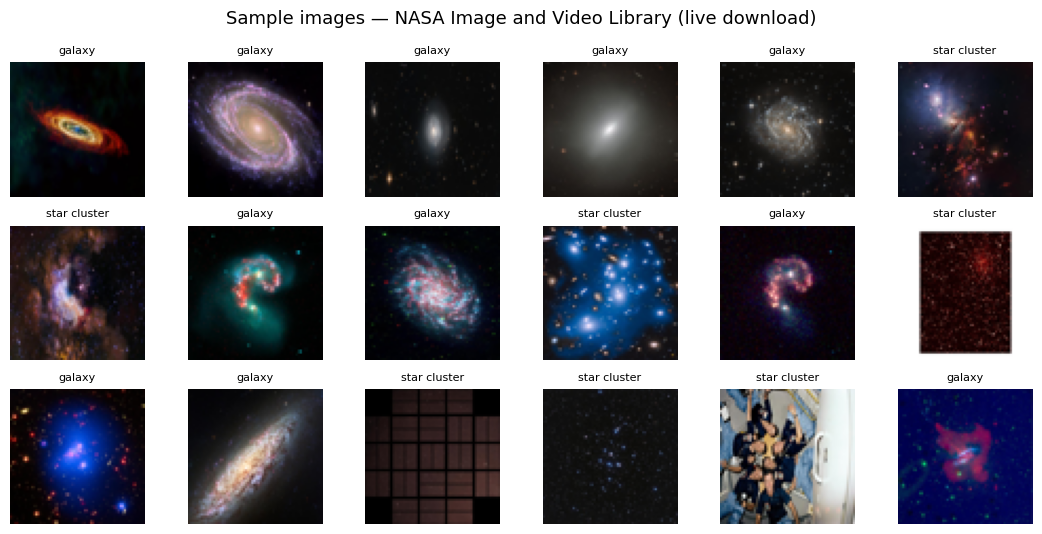

In [7]:
def show_grid(images, titles=None, rows=3, cols=6, figtitle=None):
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.8, rows * 1.8))
    for i, ax in enumerate(axes.ravel()):
        if i < len(images):
            ax.imshow(np.clip(images[i], 0, 1))
            if titles is not None:
                ax.set_title(titles[i], fontsize=8)
        ax.axis("off")
    if figtitle:
        fig.suptitle(figtitle, fontsize=13)
    plt.tight_layout()
    plt.show()

show_grid(X[:18], [CATEGORY_NAMES[c] for c in y_cat[:18]],
          figtitle=f"Sample images - {DATA_SOURCE}")

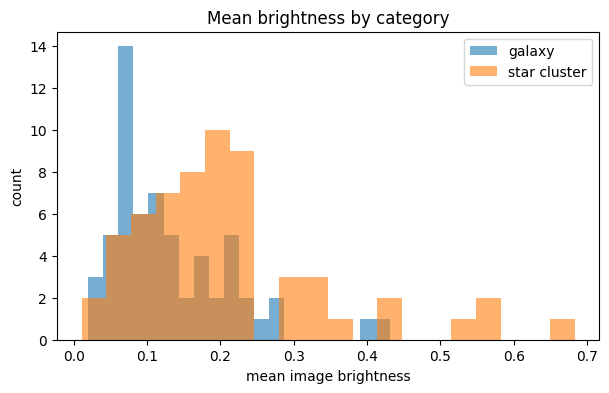

In [8]:
# Pixel-intensity distribution by category - a quick sanity check.
plt.figure(figsize=(7, 4))
for i, name in enumerate(CATEGORY_NAMES):
    vals = X[y_cat == i].mean(axis=(1, 2, 3))
    plt.hist(vals, bins=20, alpha=0.6, label=name)
plt.xlabel("mean image brightness"); plt.ylabel("count")
plt.title("Mean brightness by category"); plt.legend(); plt.show()

## 4. CNN feature learning - a convolutional auto-encoder

We train a **convolutional auto-encoder**: the *encoder* compresses each 64×64×3
image down to a `LATENT_DIM`-dimensional vector, and the *decoder* reconstructs
the image from it. After training, the encoder gives us a learned, low-dimensional
**feature embedding** of every image that we can cluster.

If TensorFlow is unavailable, we substitute PCA on the flattened pixels so the rest
of the notebook still runs.

In [9]:
def build_autoencoder(img_size=IMG_SIZE, latent=LATENT_DIM):
    from tensorflow.keras import layers, Model
    inp = layers.Input((img_size, img_size, 3))
    x = layers.Conv2D(16, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D()(x)                       # 32
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)                       # 16
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)                       # 8
    shape_before = x.shape[1:]
    x = layers.Flatten()(x)
    z = layers.Dense(latent, activation="relu", name="latent")(x)

    d = layers.Dense(int(np.prod(shape_before)), activation="relu")(z)
    d = layers.Reshape(shape_before)(d)
    d = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(d)
    d = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(d)
    d = layers.Conv2DTranspose(16, 3, strides=2, activation="relu", padding="same")(d)
    out = layers.Conv2D(3, 3, activation="sigmoid", padding="same")(d)

    autoencoder = Model(inp, out, name="conv_autoencoder")
    encoder = Model(inp, z, name="encoder")
    autoencoder.compile(optimizer="adam", loss="mse")
    return autoencoder, encoder

Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │        65,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │        67,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 3)      │           435 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,043 (668.14 KB)

 Trainable params: 171,043 (668.14 KB)

 Non-trainable params: 0 (0.00 B)

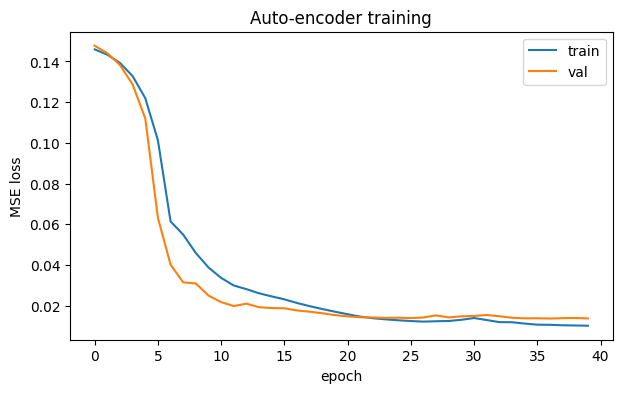

Learned feature matrix: (120, 32)


In [10]:
if TF_AVAILABLE:
    autoencoder, encoder = build_autoencoder()
    autoencoder.summary()
    history = autoencoder.fit(X, X, epochs=40, batch_size=16,
                              validation_split=0.15, verbose=0)
    plt.figure(figsize=(7, 4))
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.xlabel("epoch"); plt.ylabel("MSE loss")
    plt.title("Auto-encoder training"); plt.legend(); plt.show()
    features = encoder.predict(X, verbose=0)
else:
    from sklearn.decomposition import PCA
    flat = X.reshape(len(X), -1)
    features = PCA(n_components=LATENT_DIM, random_state=SEED).fit_transform(flat)

print("Learned feature matrix:", features.shape)

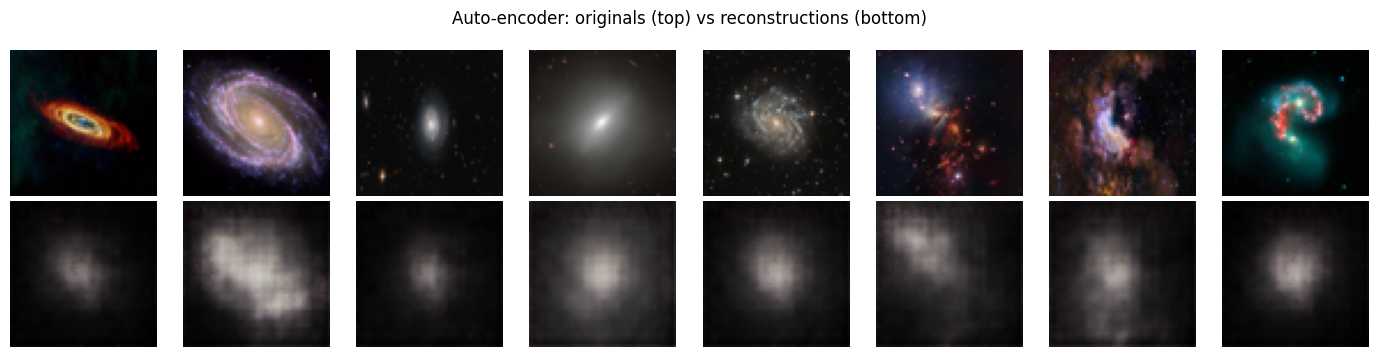

In [11]:
# Visualise reconstructions to confirm the auto-encoder learned something useful.
if TF_AVAILABLE:
    recon = autoencoder.predict(X[:8], verbose=0)
    fig, axes = plt.subplots(2, 8, figsize=(14, 3.6))
    for i in range(8):
        axes[0, i].imshow(np.clip(X[i], 0, 1));     axes[0, i].axis("off")
        axes[1, i].imshow(np.clip(recon[i], 0, 1)); axes[1, i].axis("off")
    axes[0, 0].set_ylabel("original", fontsize=10)
    axes[1, 0].set_ylabel("reconstruction", fontsize=10)
    fig.suptitle("Auto-encoder: originals (top) vs reconstructions (bottom)")
    plt.tight_layout(); plt.show()

## 5. Clustering the learned features

We standardise the embeddings and run **K-Means**. We sweep a range of cluster
counts and pick the one with the best **silhouette score** (a measure of how
well-separated the clusters are).

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

Z = StandardScaler().fit_transform(features)

scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Z)
    scores[k] = silhouette_score(Z, km.labels_)
    print(f"k={k}  silhouette={scores[k]:.3f}")

best_k = max(scores, key=scores.get)
print("\nBest k by silhouette:", best_k)
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=SEED).fit(Z)
cluster_labels = kmeans.labels_

k=2  silhouette=0.332
k=3  silhouette=0.296


k=4  silhouette=0.247


k=5  silhouette=0.246


k=6  silhouette=0.216

Best k by silhouette: 2


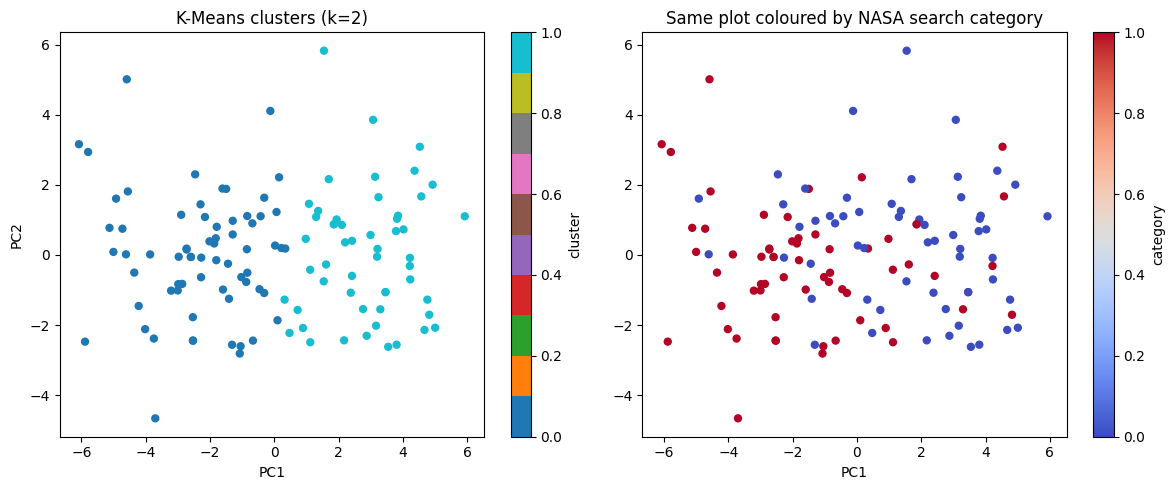

In [13]:
# Project the embeddings to 2-D with PCA and colour by cluster.
proj = PCA(n_components=2, random_state=SEED).fit_transform(Z)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sc0 = ax[0].scatter(proj[:, 0], proj[:, 1], c=cluster_labels, cmap="tab10", s=25)
ax[0].set_title(f"K-Means clusters (k={best_k})"); ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2")
plt.colorbar(sc0, ax=ax[0], label="cluster")

sc1 = ax[1].scatter(proj[:, 0], proj[:, 1], c=y_cat, cmap="coolwarm", s=25)
ax[1].set_title("Same plot coloured by NASA search category"); ax[1].set_xlabel("PC1")
plt.colorbar(sc1, ax=ax[1], label="category")
plt.tight_layout(); plt.show()

In [14]:
# How do the discovered clusters line up with the original search categories?
import pandas as pd
ct = pd.crosstab(pd.Series(cluster_labels, name="cluster"),
                 pd.Series([CATEGORY_NAMES[c] for c in y_cat], name="category"))
print("Cluster vs category contingency table:")
print(ct)

Cluster vs category contingency table:
category  galaxy  star cluster
cluster                       
0             20            47
1             40            13


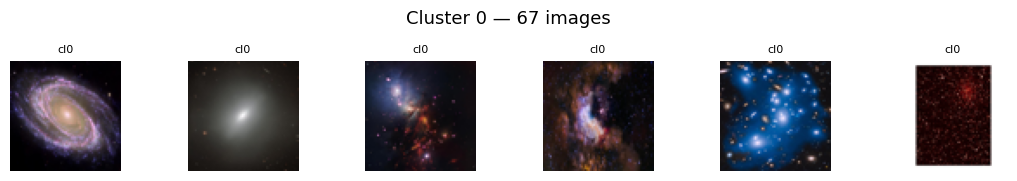

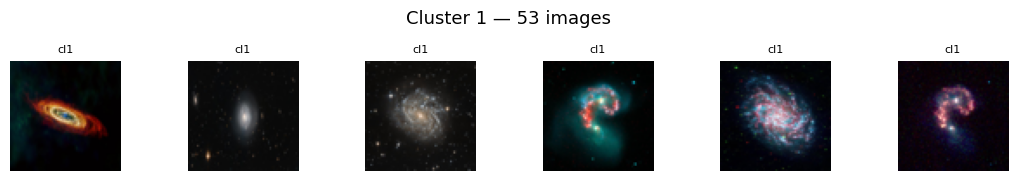

In [15]:
# Show a few representative images from each cluster.
for c in range(best_k):
    idx = np.where(cluster_labels == c)[0][:6]
    if len(idx) == 0:
        continue
    show_grid(X[idx], [f"cl{c}"] * len(idx), rows=1, cols=6,
              figtitle=f"Cluster {c} - {len(np.where(cluster_labels==c)[0])} images")

## 6. Conclusions

**What worked (and is meaningful):**
* A convolutional auto-encoder learned compact visual features directly from NASA
  imagery without any labels.
* K-Means on those features recovered morphology-driven clusters; the
  cluster-vs-category table shows how well the unsupervised grouping aligns with
  the original galaxy / star-cluster search terms.

**Limitations:**
* Sample sizes are tiny (tens of images) - fine for a demo, not for publishable results.
* NASA search results are heterogeneous (diagrams, mosaics, captions baked into images),
  so real downloads are noisier than the synthetic fallback.

*(For the deeply unserious finale, scroll on to the appendix.)*

## 🛸 Appendix - *The Galaxy Life-Detector 9000™*

> *"Is this picture of a galaxy alive?"* - nobody serious, ever.

Welcome to the deeply unscientific portion of the notebook. SETI has spent
decades scanning the cosmos with billion-dollar radio telescopes and largely
heard static. We're going to "solve" the same problem with a 64×64 JPEG and a
three-layer CNN. Results may vary by approximately ∞.

The bit: there is **no ground-truth dataset of "images that contain life"**, so
we just make one up. Our `habitability_proxy()` declares a galaxy "habitable" if
it has moderate brightness and high local structure - a rule with the
scientific rigour of *vibes*. We then train a real CNN to learn this rule,
which it does, beautifully and incorrectly, in the only sense the universe
cares about.

If the model tells you a galaxy hosts life, please do **not** call NASA - they
are busy. Real astrobiology uses **transmission spectroscopy of exoplanet
atmospheres**, not deep learning on cropped Hubble screenshots.

**TL;DR** - this section trains a real CNN to predict a fake label very well.
It is the machine-learning equivalent of teaching a parrot to say *"I am
conscious"*: impressive engineering, philosophically irrelevant.

In [16]:
def habitability_proxy(images):
    # Fabricated, illustrative target -- NOT science. Returns 0/1 labels.
    feats = []
    for im in images:
        g = im.mean(axis=2)
        brightness = g.mean()
        contrast   = g.std()
        # local structure: variance of a coarse gradient
        gx = np.abs(np.diff(g, axis=0)).mean()
        gy = np.abs(np.diff(g, axis=1)).mean()
        structure = gx + gy
        feats.append([brightness, contrast, structure])
    feats = np.array(feats)
    # "Goldilocks" vibes: moderate brightness AND high structure -> label 1
    bn = (feats - feats.mean(0)) / (feats.std(0) + 1e-8)
    score = -np.abs(bn[:, 0]) + bn[:, 1] * 0.5 + bn[:, 2]      # arbitrary
    return (score > np.median(score)).astype(int), feats

y_life, proxy_feats = habitability_proxy(X)
print("Fake 'life' label balance:", {int(k): int(v) for k, v in zip(*np.unique(y_life, return_counts=True))})

Fake 'life' label balance: {0: 60, 1: 60}


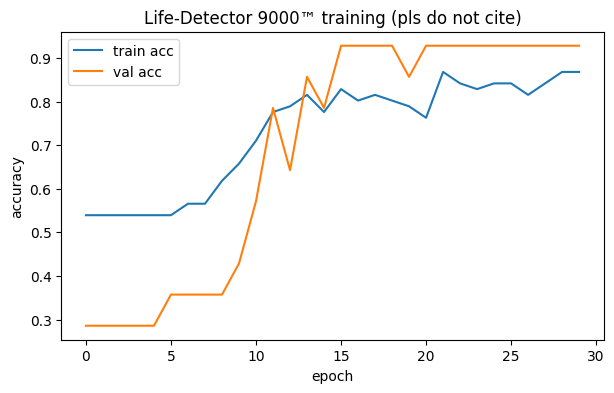

Confusion matrix:
 [[11  4]
 [ 3 12]]

Classification report:
                       precision    recall  f1-score   support

 dead galaxy (vibes)       0.79      0.73      0.76        15
alive galaxy (vibes)       0.75      0.80      0.77        15

            accuracy                           0.77        30
           macro avg       0.77      0.77      0.77        30
        weighted avg       0.77      0.77      0.77        30



In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

Xtr, Xte, ytr, yte = train_test_split(X, y_life, test_size=0.25,
                                      random_state=SEED, stratify=y_life)

if TF_AVAILABLE:
    from tensorflow.keras import layers, Model
    inp = layers.Input((IMG_SIZE, IMG_SIZE, 3))
    x = layers.Conv2D(16, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    clf = Model(inp, out, name="life_detector_9000")
    clf.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    hist = clf.fit(Xtr, ytr, validation_split=0.15, epochs=30, batch_size=16, verbose=0)

    plt.figure(figsize=(7, 4))
    plt.plot(hist.history["accuracy"], label="train acc")
    plt.plot(hist.history["val_accuracy"], label="val acc")
    plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend()
    plt.title("Life-Detector 9000™ training (pls do not cite)"); plt.show()

    proba = clf.predict(Xte, verbose=0).ravel()
    pred = (proba > 0.5).astype(int)
else:
    from sklearn.neural_network import MLPClassifier
    mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=SEED)
    mlp.fit(Xtr.reshape(len(Xtr), -1), ytr)
    pred = mlp.predict(Xte.reshape(len(Xte), -1))

print("Confusion matrix:\n", confusion_matrix(yte, pred))
print("\nClassification report:\n",
      classification_report(yte, pred, target_names=["dead galaxy (vibes)", "alive galaxy (vibes)"]))

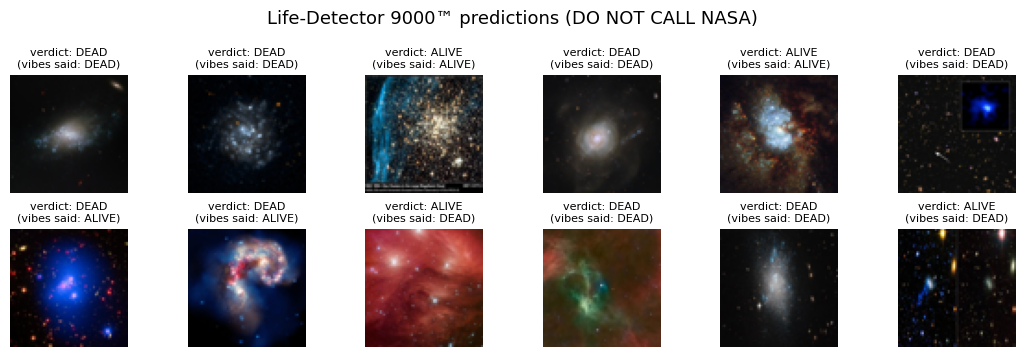

In [18]:
# Visualise a few test predictions. Remember: the label is fictional.
n = min(12, len(Xte))
titles = [f"verdict: {'ALIVE' if pred[i] else 'DEAD'}\n(vibes said: {'ALIVE' if yte[i] else 'DEAD'})" for i in range(n)]
show_grid(Xte[:n], titles, rows=2, cols=6,
          figtitle="Life-Detector 9000™ predictions (DO NOT CALL NASA)")